In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew,kurtosis,zscore

In [3]:
data = pd.read_csv("D:/Projects/EDA_Sales/Diwali Sales Data.csv",encoding='ISO-8859-1')
data.drop(['Status','unnamed1'],axis = 1,inplace = True)

<h1 style="color:red;">Data Understanding</h1>

# 1a) Basic Understanding

In [4]:
data.head(5)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [5]:
data.tail(5)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0


In [6]:
data.shape

(11251, 13)

In [7]:
print(f"There are total {len(data["Gender"].unique())} unique Gender in the DataSet. There are : ")
for i,item in enumerate(data["Gender"].unique()):
    print(str(i+1)+". ",item)

There are total 2 unique Gender in the DataSet. There are : 
1.  F
2.  M


In [8]:
print(f"There are total {len(data["Age Group"].unique())} unique Age Groups in the DataSet. There are : ")
for i,item in enumerate(data["Age Group"].unique()):
    print(str(i+1)+". ",item)


There are total 7 unique Age Groups in the DataSet. There are : 
1.  26-35
2.  0-17
3.  18-25
4.  55+
5.  46-50
6.  51-55
7.  36-45


In [9]:
print(f"There are total {len(data["Marital_Status"].unique())} unique Marital_Status in the DataSet. There are : ")
for i,item in enumerate(data["Marital_Status"].unique()):
    print(str(i+1)+". ",item)

There are total 2 unique Marital_Status in the DataSet. There are : 
1.  0
2.  1


In [10]:
print(f"There are total {len(data["State"].unique())} unique State in the DataSet. There are : ")
for i,item in enumerate(data["State"].unique()):
    print(str(i+1)+". ",item)

There are total 16 unique State in the DataSet. There are : 
1.  Maharashtra
2.  Andhra Pradesh
3.  Uttar Pradesh
4.  Karnataka
5.  Gujarat
6.  Himachal Pradesh
7.  Delhi
8.  Madhya Pradesh
9.  Jharkhand
10.  Kerala
11.  Haryana
12.  Bihar
13.  Rajasthan
14.  Uttarakhand
15.  Telangana
16.  Punjab


In [11]:
print(f"There are total {len(data["Zone"].unique())} unique Zone in the DataSet. There are : ")
for i,item in enumerate(data["Zone"].unique()):
    print(str(i+1)+". ",item)

There are total 5 unique Zone in the DataSet. There are : 
1.  Western
2.  Southern
3.  Central
4.  Northern
5.  Eastern


In [12]:
print(f"There are total {len(data["Occupation"].unique())} unique Occupation in the DataSet. There are : ")
for i,item in enumerate(data["Occupation"].unique()):
    print(str(i+1)+". ",item)

There are total 15 unique Occupation in the DataSet. There are : 
1.  Healthcare
2.  Govt
3.  Automobile
4.  Construction
5.  Food Processing
6.  Lawyer
7.  IT Sector
8.  Media
9.  Banking
10.  Retail
11.  Hospitality
12.  Aviation
13.  Agriculture
14.  Textile
15.  Chemical


In [13]:
print(f"There are total {len(data["Product_Category"].unique())} unique Product_Category in the DataSet. There are : ")
for i,item in enumerate(data["Product_Category"].unique()):
    print(str(i+1)+". ",item)

There are total 18 unique Product_Category in the DataSet. There are : 
1.  Auto
2.  Hand & Power Tools
3.  Stationery
4.  Tupperware
5.  Footwear & Shoes
6.  Furniture
7.  Food
8.  Games & Toys
9.  Sports Products
10.  Books
11.  Electronics & Gadgets
12.  Decor
13.  Clothing & Apparel
14.  Beauty
15.  Household items
16.  Pet Care
17.  Veterinary
18.  Office


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [15]:
data.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


# 1b) Understanding the data distribution

In [16]:
numerical_columns = data.select_dtypes(include = ['number']).columns.tolist()

In [17]:
SkewSum = 0 
KurtosisSum = 0
n = len(numerical_columns)

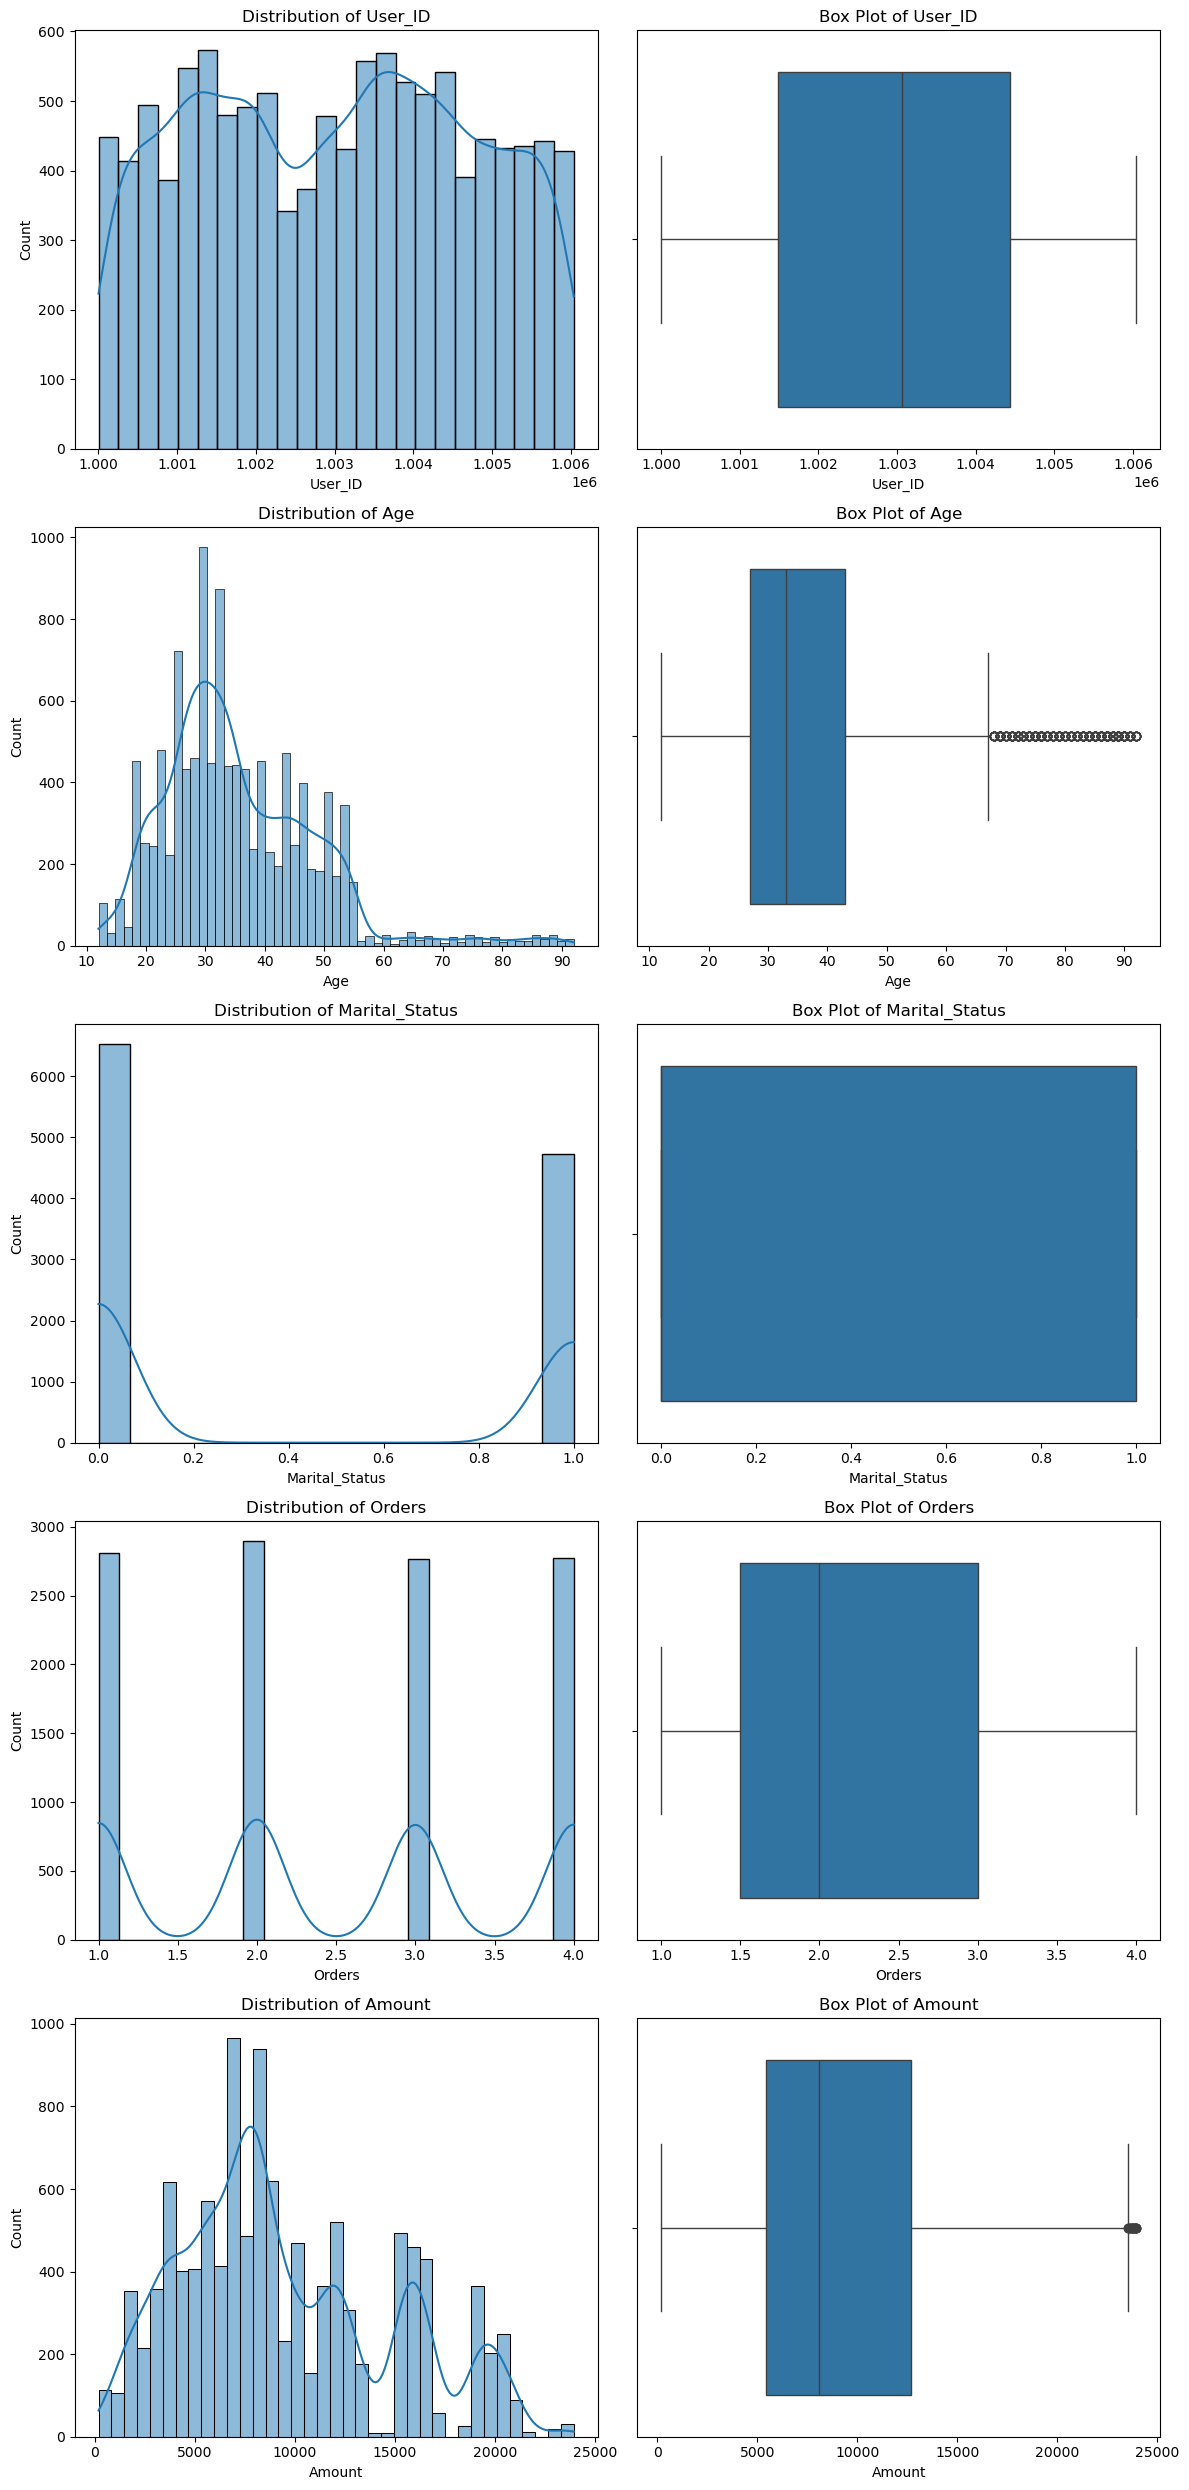

In [18]:

fig, axes = plt.subplots(n,2,figsize = (12,5*n))

for i,col in enumerate(numerical_columns):

    SkewSum += data[col].skew()
    KurtosisSum += data[col].kurtosis()

    sns.histplot(data[col],kde = True,ax = axes[i,0])
    axes[i,0].set_title("Distribution of "+col)
    
    sns.boxplot(x=data[col],ax = axes[i,1])
    axes[i,1].set_title("Box Plot of "+col)
    
plt.tight_layout()
plt.show()
    
    

In [19]:
avgskew = SkewSum/n
print("Average Skewness of the given dataset : ",avgskew)

if abs(avgskew) < 0.1:
    print("Normal Distribution")
elif avgskew > 0:
    print("Right Skewed.")
else:
    print("Left skewed.")

Average Skewness of the given dataset :  0.4173275647006617
Right Skewed.


In [20]:
avgKurtosis = KurtosisSum/n
print("Average Kurtosis of the given dataset : ",avgKurtosis)

if abs(avgKurtosis) < 0.1:
    print("Normal Distribution")
elif avgKurtosis > 0:
    print("More Outliers")
else:
    print("Less Outliers")

Average Kurtosis of the given dataset :  -0.5001075932490598
Less Outliers


<h1 style="color:red;">2) Data Cleaning</h1>

## 2a) Understanding the missing values

In [21]:
#Missing Values column wise
data.isna().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [22]:
#Total Missing Values
data.isna().sum().sum()

12

In [23]:
#Total Percentage of Missing Values
(data.isna().sum().sum()/len(data))*100

0.10665718602790863

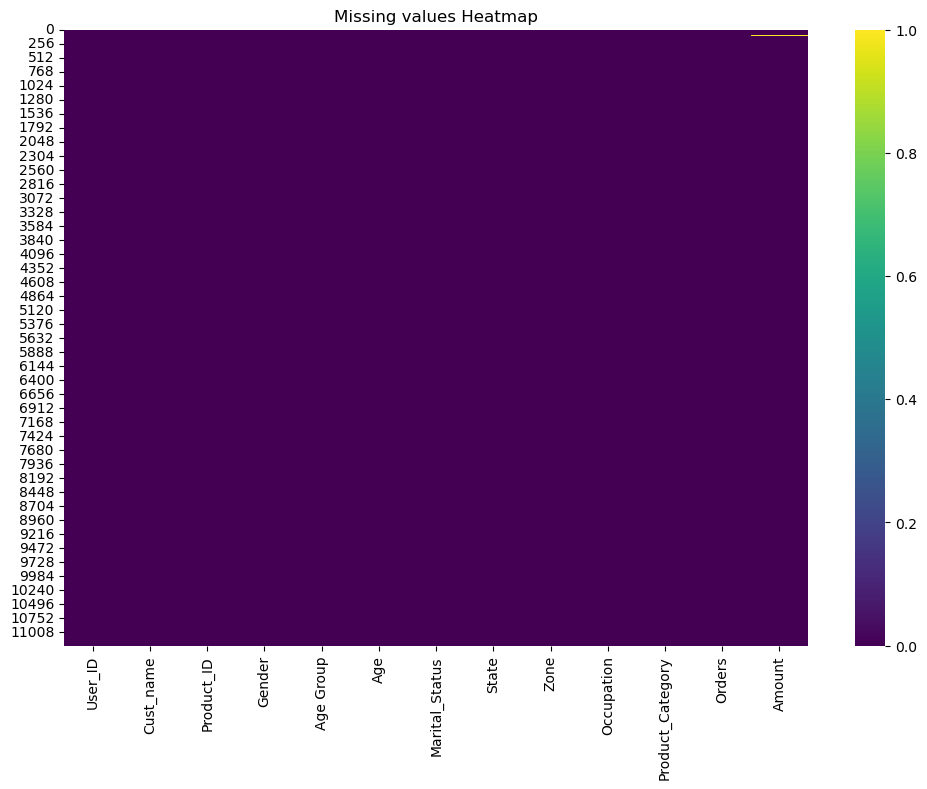

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cmap="viridis")
plt.title("Missing values Heatmap")
plt.show()

<Axes: >

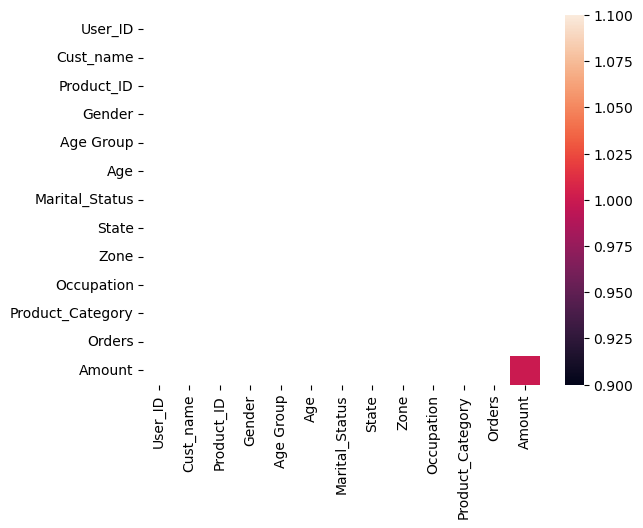

In [25]:
#Shows correlation with the other column 
sns.heatmap(data.isnull().corr())

## 2b) Handling the missing Values

In [26]:

def dataCleaning(data,feature,method="remove"):
    data_copy = data.copy()
    if method == "remove":
        #Removes the null rows
        data_copy.dropna(subset=[feature],inplace = True)
    elif method == "mean":
        #Imputes with mean
        data_copy[feature].fillna(data[feature].mean(),inplace = True)
    elif method == "median":
        #imputes with median
        data_copy[feature].fillna(data[feature].median(),inplace = True)
    elif method == "mode":
        #imputes with mode
        data_copy[feature].fillna(data[feature].mode()[0],inplace=True)
    elif method == "interpolate":
        #calculate the missing values with the help of previous and next values
        data_copy[feature].interpolate(inplace = True)
    elif method == "forwardfill":
        #fills the prev one 
        data_copy[feature].fillna(method='ffill')
    elif method == "backwardfill":
        #fills with next one
        data_copy[feature].fillna(method='bfill')
    else:
        print('Enter the correct method')
    return data_copy
        
        
    

In [27]:
# For numerical columns - use the methods remove, mean, median, interploate, forwardfill, backwardfill, mode
# For categorical columns - use the methods like remove, mode, forwardfill, backwardfill, mode
cleaned_data = dataCleaning(data,"Amount","remove")

In [28]:
#checking whether the data is cleaned or not
cleaned_data.isna().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

<h1 style="color:red;">3) Outliers</h1>

# 3a) Numerical Columns

### i) Outlier Analysis for Numerical Columns 

In [29]:
avgskew = SkewSum/n
print("Average Skewness of the given dataset : ",avgskew)

if abs(avgskew) < 0.1:
    print("Normal Distribution")
elif avgskew > 0:
    print("Right Skewed. Outliers mostly at right")
else:
    print("Left skewed. Outliers mostly at left")

Average Skewness of the given dataset :  0.4173275647006617
Right Skewed. Outliers mostly at right


In [30]:
avgKurtosis = KurtosisSum/n
print("Average Kurtosis of the given dataset : ",avgKurtosis)

if abs(avgKurtosis) < 0.1:
    print("Normal Distribution")
elif avgKurtosis > 0:
    print("More Outliers")
else:
    print("Less Outliers")

Average Kurtosis of the given dataset :  -0.5001075932490598
Less Outliers


### ii) Outlier Detection for Numerical columns

In [31]:
def NumericaloutlierDetection(data,method = 'zscore',threshold = 3):
    if method == "zscore":
        z_scores = np.abs(zscore(data))
        outliers = z_scores > threshold
        return outliers
    elif method == "IQR":
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = (data < (Q1 - threshold*IQR)) | (data > (Q3 + threshold*IQR))
        return outliers
    else:
        print("Enter the correct method")
    

### iii) Outlier Handling for Numerical Columns

In [32]:
def handleNumericalOutliers(cleaned_data,outliers,feature = None,method = 'cap',threshold = 1.5):
    if feature is None:
        print("Please provide a feature name for 'median' method.")
        return cleaned_data

    copy_data = cleaned_data.copy()
    
    if method == "remove":
        copy_data = copy_data[~outliers[feature]]
        
    elif method == "cap":
        Q1 = copy_data[feature].quantile(0.25)
        Q3 = copy_data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold*IQR
        upper_bound = Q3 + threshold*IQR
        copy_data[feature] = np.clip(copy_data[feature],lower_bound,upper_bound)
        
    elif method == "median":
    
        median = copy_data.loc[~outliers[feature],feature].median()
        copy_data.loc[outliers[feature],feature] = median


        
    elif method == "log":
        copy_data[feature] = np.log1p(copy_data[feature])
    else:
        print("Give the correct method")
    return copy_data
        
    

In [33]:
numerical_data = cleaned_data.select_dtypes(include = ['number'])
outliers = NumericaloutlierDetection(numerical_data,"IQR",1.5)
print('Outliers column wise')
outliers.sum()

Outliers column wise


User_ID             0
Age               283
Marital_Status      0
Orders              0
Amount             19
dtype: int64

# 3b) Categorical Columns

### i) Outlier Handling for Categorical Columns

In [34]:
def CategoricaloutlierDetection(cleaned_data, threshold=5):
    categorical_columns = cleaned_data.select_dtypes(include=['object']).columns.tolist()
    outlier_dict = {}
    print('Outliers in categorical columns with count:')
    for column in categorical_columns:
        value_counts = cleaned_data[column].value_counts()
        rare_categories = value_counts[value_counts < threshold].index
        if len(rare_categories) > 0:
            outlier_dict[column] = rare_categories
            print(f"{column}: {len(rare_categories)}")
    return outlier_dict

### ii) Handling Categorical Outliers

In [35]:
def handleCategoricalOutliers(df, categoricalOutliers,column, method='mode'):
    copy_df = df.copy()
    if method == 'remove':
        copy_df = copy_df[~copy_df[column].isin(categoricalOutliers)]
    
    elif method == 'mode':
        if not copy_df[column].mode().empty:
            mode = copy_df[column].mode()[0]
            copy_df[column] = copy_df[column].apply(lambda x: mode if x in categoricalOutliers else x)

    elif method == 'other':
        copy_df[column] = copy_df[column].apply(lambda x: 'Other' if x in categoricalOutliers else x)

    else:
        print("No method with the name ",method)

    return copy_df

In [36]:
categoricalOutliers = CategoricaloutlierDetection(cleaned_data, 5)

Outliers in categorical columns with count:
Cust_name: 142
Product_ID: 1512


 <h1 style="color:red;">4) Data Analysis</h1>

## 4a) Univariate Analysis

### i) Numerical Columns

In [37]:
def univariateAnalysis(df,feature = None,plot="hist"):
    if plot == "hist":
        sns.histplot(data=df,x=feature,kde=False,bins=10)
        plt.title("Histogram of "+feature)
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.show()
    elif plot == "box":
        sns.boxplot(y=feature,data=df)
        plt.title("Box Plot of "+feature)
        plt.ylabel(feature)
        plt.show()
    elif plot == "violin":
        sns.violinplot(data=df,y=feature)
        plt.title("violin plot of "+feature)
        plt.ylabel(feature)
        plt.show()
    elif plot == "kde":
        sns.kdeplot(x=df[feature],shade = True)
        plt.title("KDE of "+feature)
        plt.xlabel(feature)
        plt.ylabel("Density")
        plt.show()
    else:
        print("Invalid Plot")
        
        

In [38]:
num = cleaned_data.select_dtypes(include=['number']).columns
num

Index(['User_ID', 'Age', 'Marital_Status', 'Orders', 'Amount'], dtype='object')

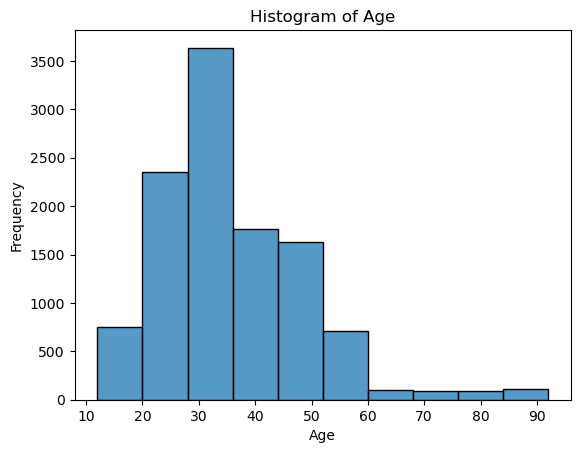

In [39]:
univariateAnalysis(cleaned_data,"Age","hist")

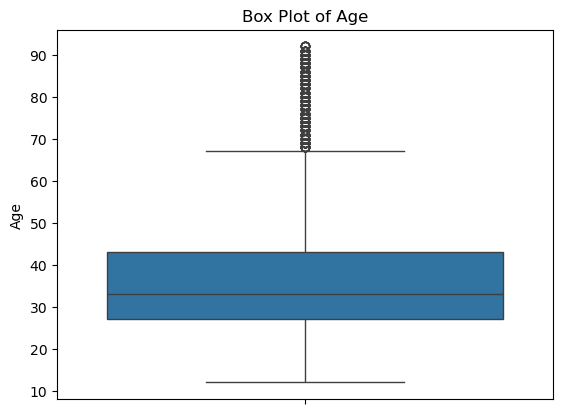

In [40]:
univariateAnalysis(cleaned_data,"Age","box")

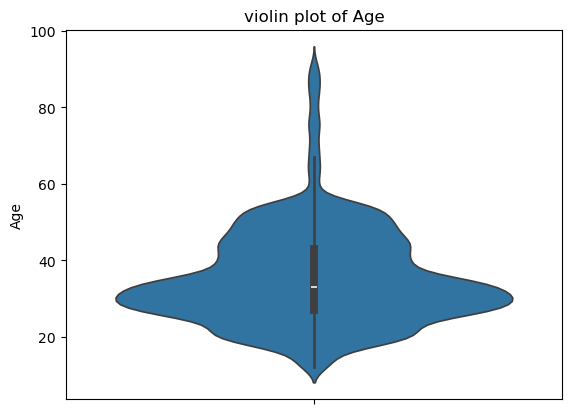

In [41]:
univariateAnalysis(cleaned_data,"Age","violin")

C:\Users\pashi\AppData\Local\Temp\ipykernel_31116\328589948.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df[feature],shade = True)


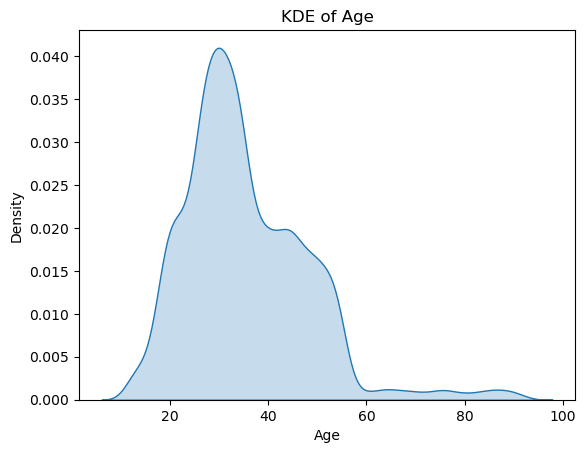

In [42]:
univariateAnalysis(cleaned_data,"Age","kde")

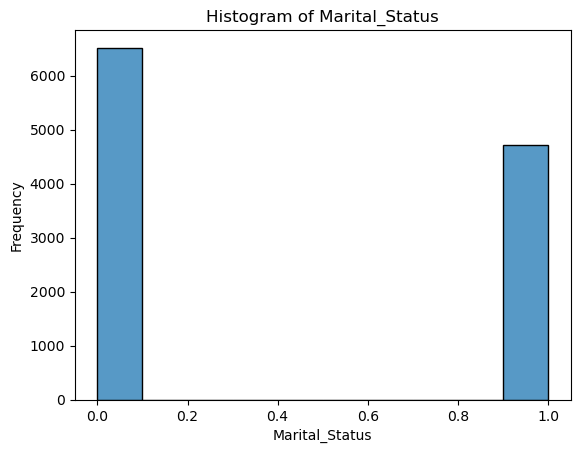

In [43]:
univariateAnalysis(cleaned_data,"Marital_Status","hist")

## ii) Categorical Columns

In [44]:
def categoricalUnivariateAnalysis(df,feature=None,plot="count"):
    if plot == "count":
        sns.countplot(y=feature,data=df)
        plt.title("Count Plot of "+feature)
        plt.xlabel("Count")
        plt.ylabel(feature)
        plt.show()
    elif plot == "pie":
        df[feature].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
        plt.title("Pie Chart of "+feature)
        plt.ylabel("") 
        plt.show()
    else:
        print("Invalid plot")

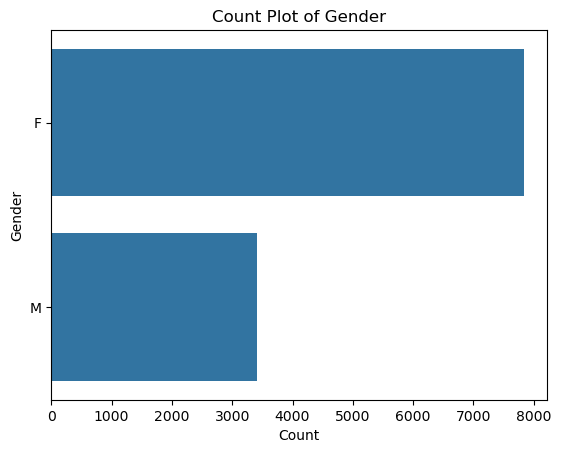

In [45]:
categoricalUnivariateAnalysis(cleaned_data,"Gender","count")

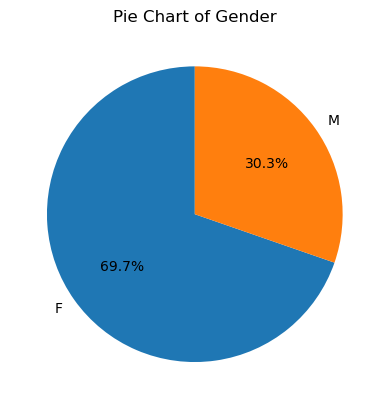

In [46]:
categoricalUnivariateAnalysis(cleaned_data,"Gender","pie")

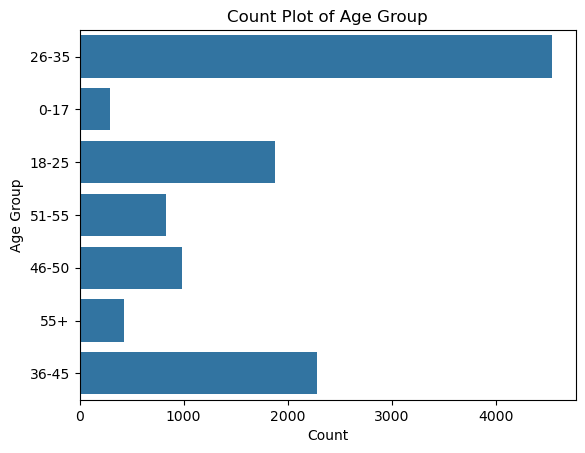

In [47]:
categoricalUnivariateAnalysis(cleaned_data,"Age Group","count")

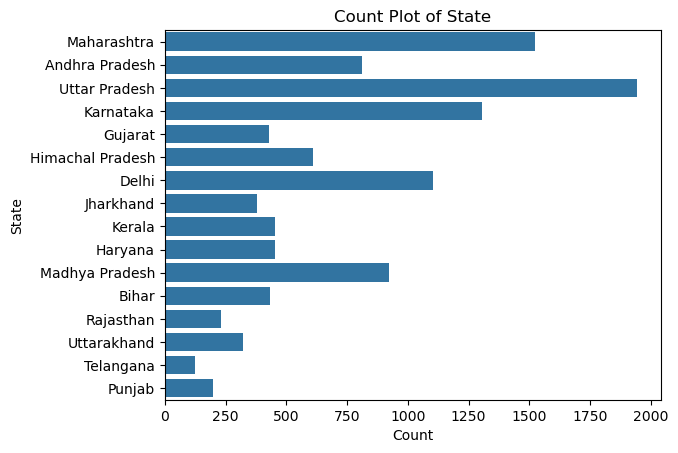

In [48]:
categoricalUnivariateAnalysis(cleaned_data,"State","count")

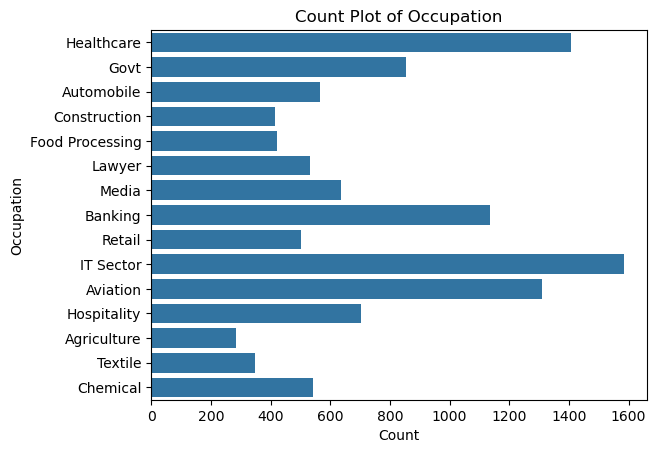

In [49]:
categoricalUnivariateAnalysis(cleaned_data,"Occupation","count")

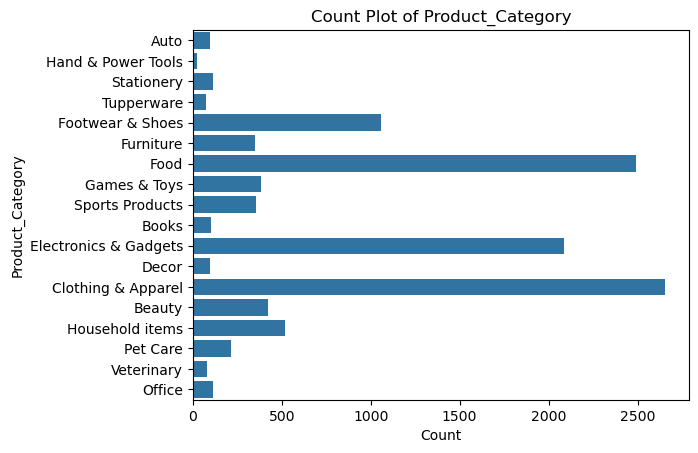

In [50]:
categoricalUnivariateAnalysis(cleaned_data,"Product_Category","count")

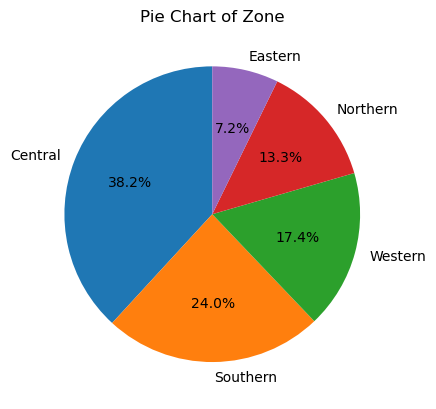

In [51]:
categoricalUnivariateAnalysis(cleaned_data,"Zone","pie")

## 4b) Bivariate Analysis

### Numerical Vs Numerical

In [52]:
def NumericalVsNumerical(df,col1,col2,plot="hist",bins=0):
    if plot == "hist":
        sns.histplot(x = col1,hue = col2,data=df,kde = True,bins = 10)
        plt.title("Histogram of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    elif plot == "scatter":
        sns.scatterplot(x = col1,y = col2,data = df)
        plt.title("ScatterPlot of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    elif plot == "line":
        sns.lineplot(x = col1,y = col2,data = df)
        plt.title("LinePlot of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    else:
        print("Invalid Plot")
        
        

In [53]:
num = cleaned_data.select_dtypes(include = ['number']).columns
num

Index(['User_ID', 'Age', 'Marital_Status', 'Orders', 'Amount'], dtype='object')

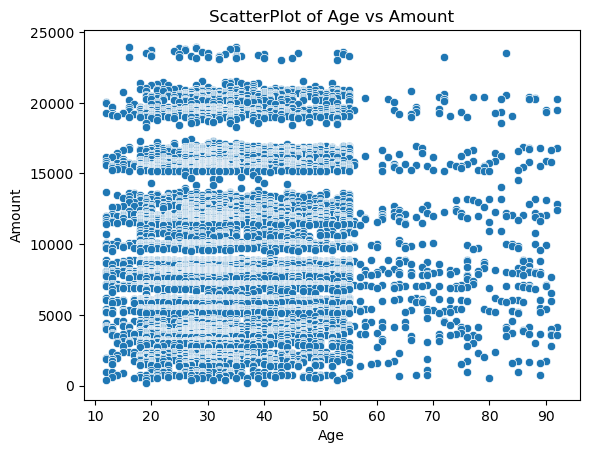

In [54]:
NumericalVsNumerical(cleaned_data,"Age","Amount","scatter")

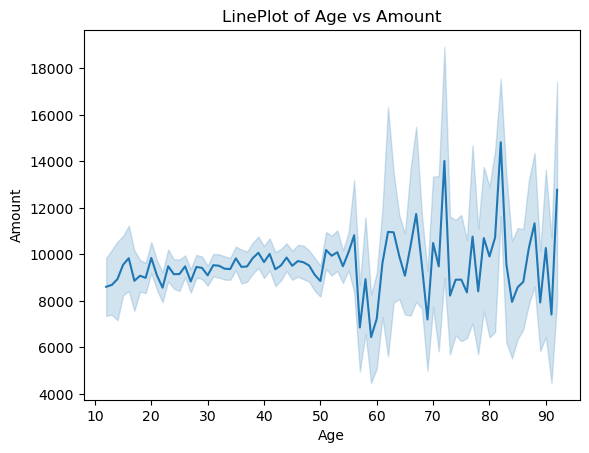

In [55]:
NumericalVsNumerical(cleaned_data,"Age","Amount","line")

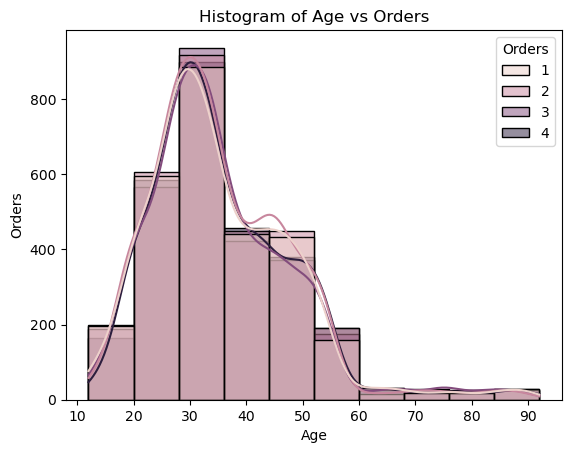

In [56]:
NumericalVsNumerical(cleaned_data,"Age","Orders","hist")

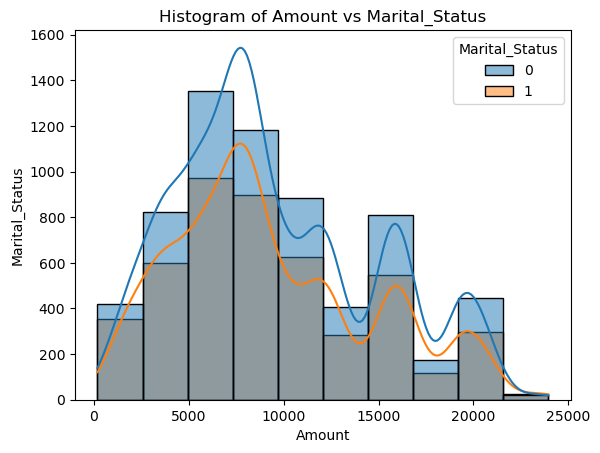

In [57]:
NumericalVsNumerical(cleaned_data,"Amount","Marital_Status","hist",100)

### Numerical Vs Categorical

In [58]:
def NumericalVsCategorical(df,col1,col2,plot="box"):
    if plot == "box":
        sns.boxplot(x = col1,y = col2,data =df)
        plt.title("BoxPlot of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    elif plot == "violin":
        sns.violinplot(x = col1,y = col2,data =df)
        plt.title("ViolinPlot of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    elif plot == "bar":
        sns.barplot(x = col1,y = col2,data = df,estimator = np.mean)
        plt.title("BarPlot of "+col1+" vs "+col2)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
    else:
        print("Invalid Plot")
        

In [59]:
num

Index(['User_ID', 'Age', 'Marital_Status', 'Orders', 'Amount'], dtype='object')

In [60]:
cat = cleaned_data.select_dtypes(include = ['object']).columns
cat

Index(['Cust_name', 'Product_ID', 'Gender', 'Age Group', 'State', 'Zone',
       'Occupation', 'Product_Category'],
      dtype='object')

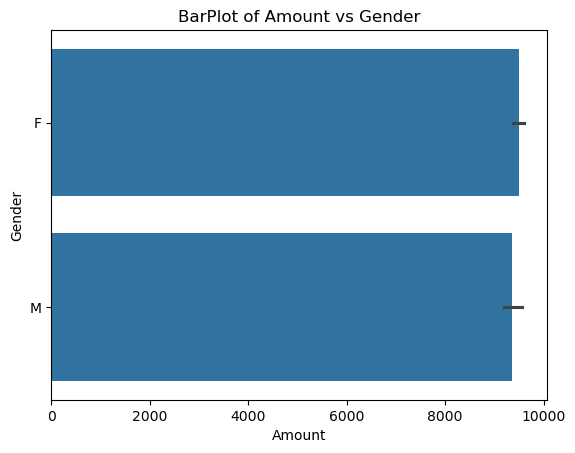

In [61]:
NumericalVsCategorical(cleaned_data,"Amount","Gender","bar")

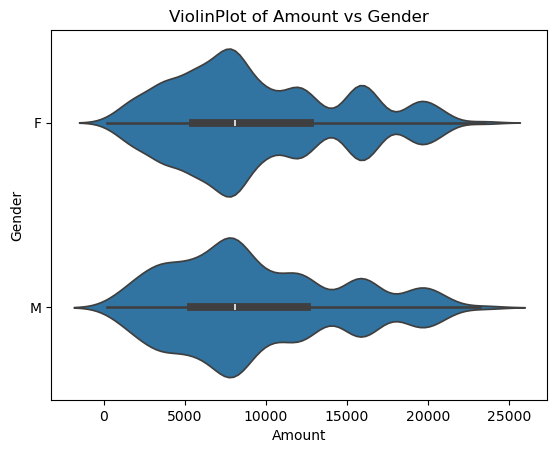

In [62]:
NumericalVsCategorical(cleaned_data,"Amount","Gender","violin")

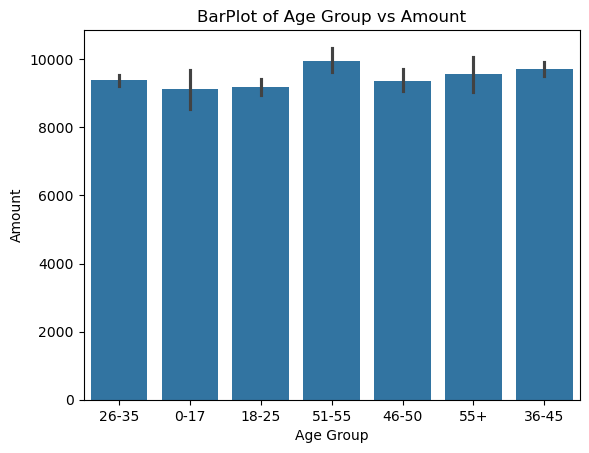

In [63]:
NumericalVsCategorical(cleaned_data,"Age Group","Amount","bar")

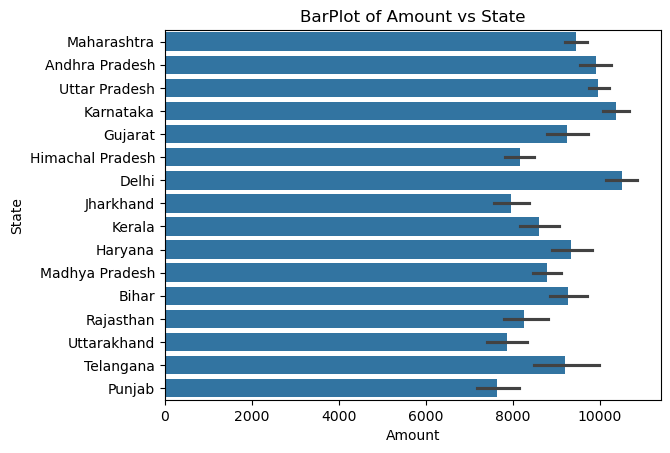

In [64]:
NumericalVsCategorical(cleaned_data,"Amount","State","bar")

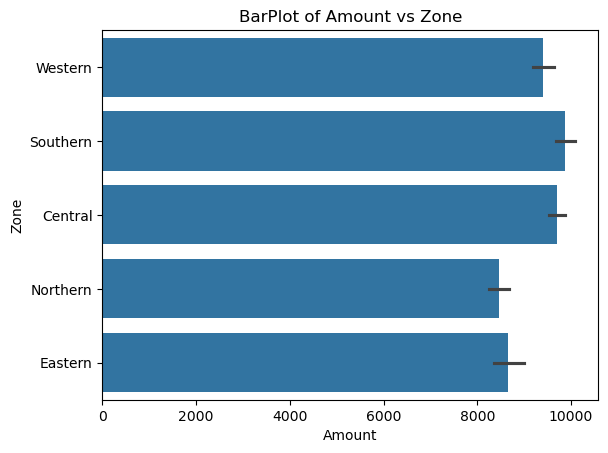

In [65]:
NumericalVsCategorical(cleaned_data,"Amount","Zone","bar")

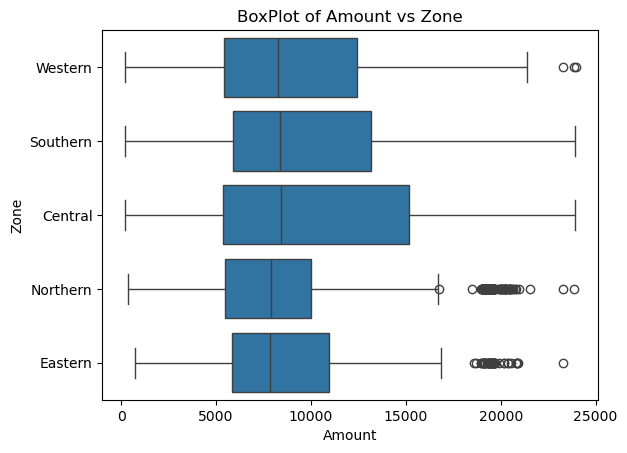

In [66]:
NumericalVsCategorical(cleaned_data,"Amount","Zone","box")

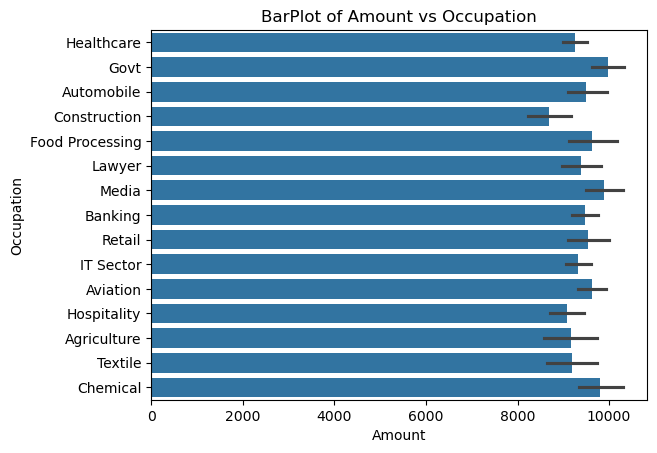

In [67]:
NumericalVsCategorical(cleaned_data,"Amount","Occupation","bar")

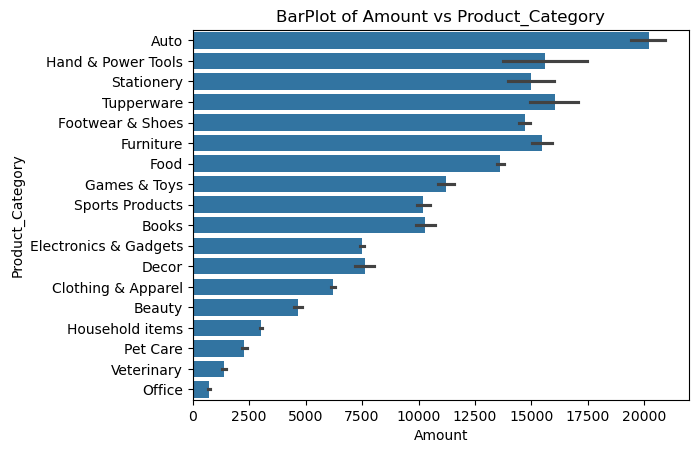

In [68]:
NumericalVsCategorical(cleaned_data,"Amount","Product_Category","bar")

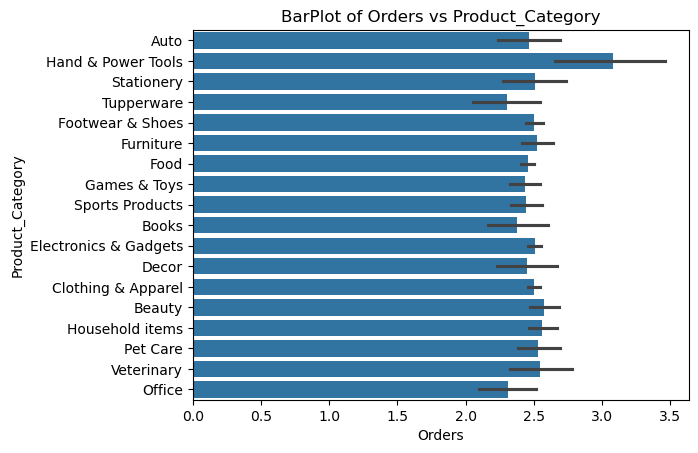

In [69]:
NumericalVsCategorical(cleaned_data,"Orders","Product_Category","bar")

### Categorical Vs Categorical

In [70]:
def CategoricalVsCategorical(df,col1,col2,plot="count"):
    if plot == "count":
        sns.countplot(x = col1,hue = col2,data=df)
        plt.title("CountPlot of "+col1+" vs "+col2)
        plt.xticks(rotation=90)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()
        
    

In [71]:
cat

Index(['Cust_name', 'Product_ID', 'Gender', 'Age Group', 'State', 'Zone',
       'Occupation', 'Product_Category'],
      dtype='object')

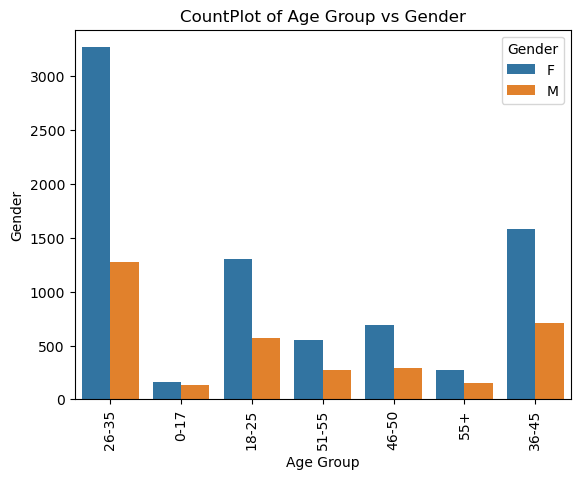

In [72]:
CategoricalVsCategorical(cleaned_data,"Age Group","Gender")

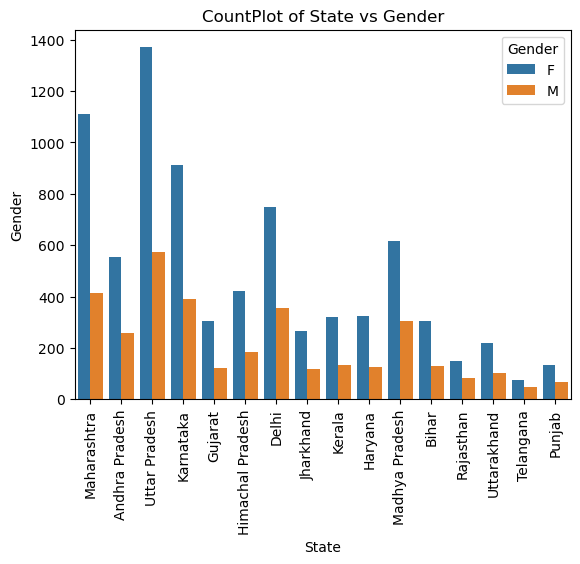

In [73]:
CategoricalVsCategorical(cleaned_data,"State","Gender")

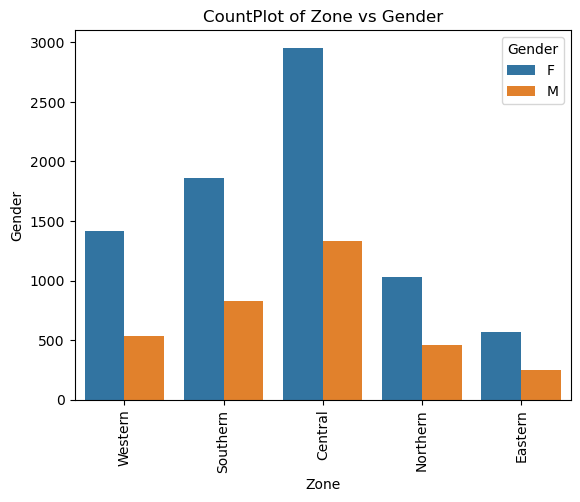

In [74]:
CategoricalVsCategorical(cleaned_data,"Zone","Gender")

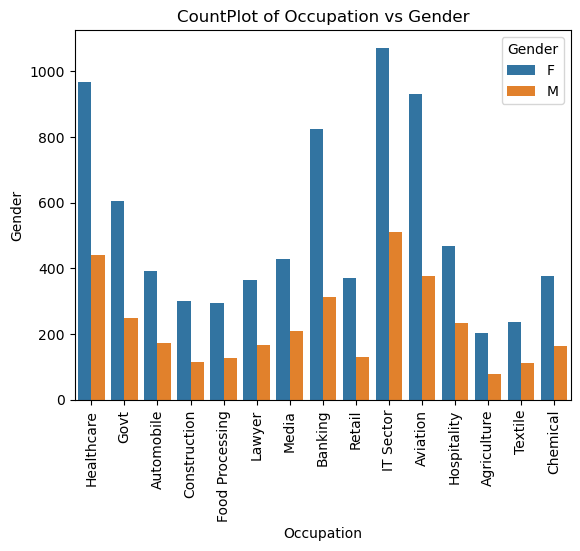

In [75]:
CategoricalVsCategorical(cleaned_data,"Occupation","Gender")

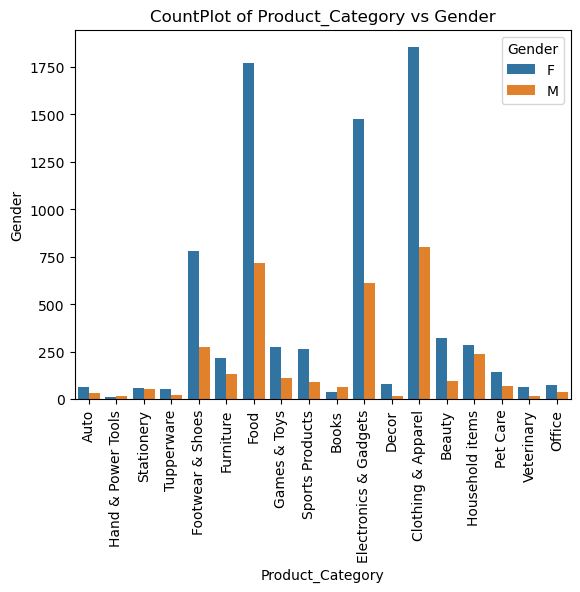

In [76]:
CategoricalVsCategorical(cleaned_data,"Product_Category","Gender")

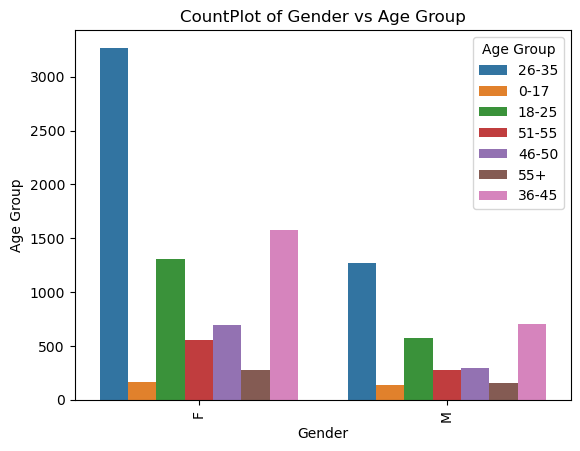

In [77]:
CategoricalVsCategorical(cleaned_data,"Gender","Age Group")

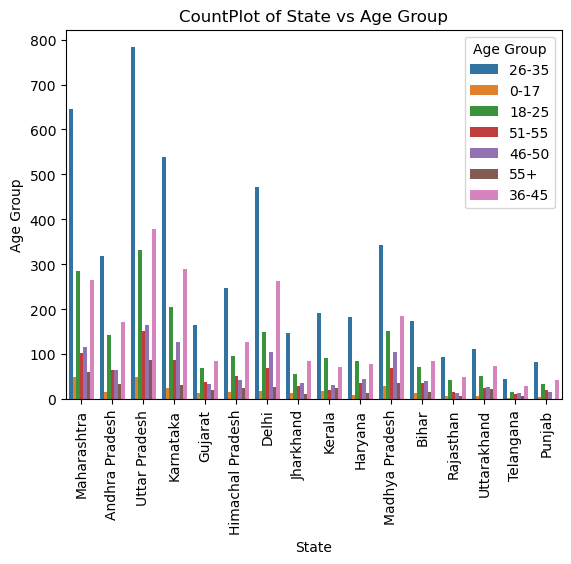

In [78]:
CategoricalVsCategorical(cleaned_data,"State","Age Group")

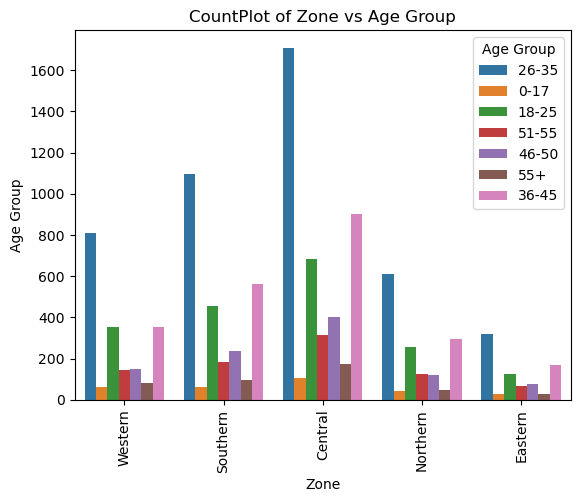

In [79]:
CategoricalVsCategorical(cleaned_data,"Zone","Age Group")

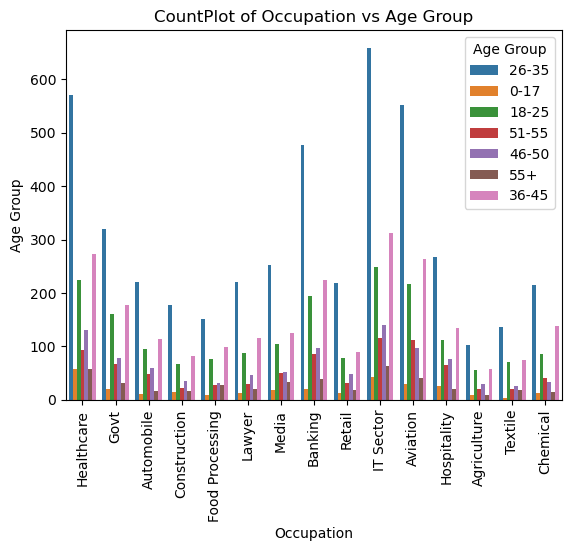

In [80]:
CategoricalVsCategorical(cleaned_data,"Occupation","Age Group")

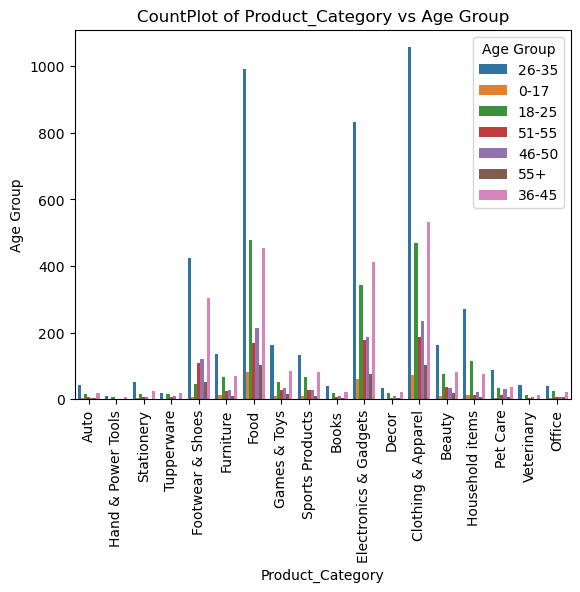

In [81]:
CategoricalVsCategorical(cleaned_data,"Product_Category","Age Group")

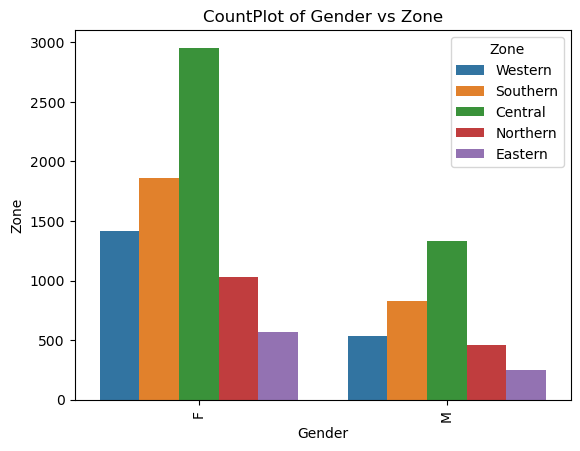

In [82]:
CategoricalVsCategorical(cleaned_data,"Gender","Zone")

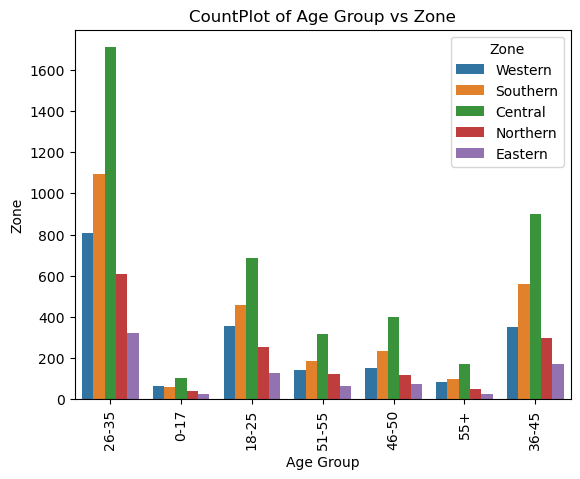

In [83]:
CategoricalVsCategorical(cleaned_data,"Age Group","Zone")

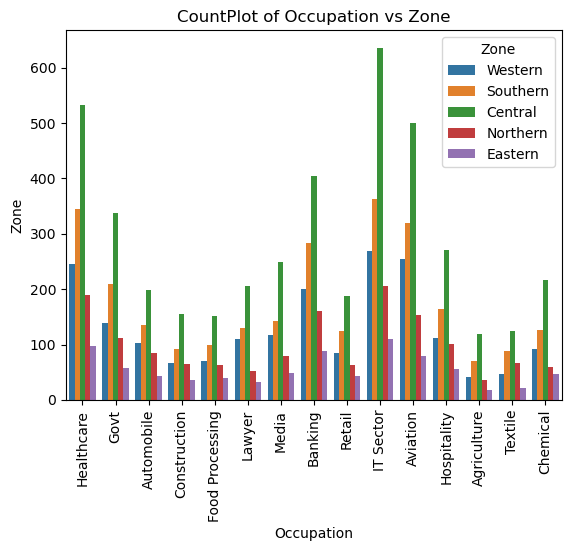

In [84]:
CategoricalVsCategorical(cleaned_data,"Occupation","Zone")

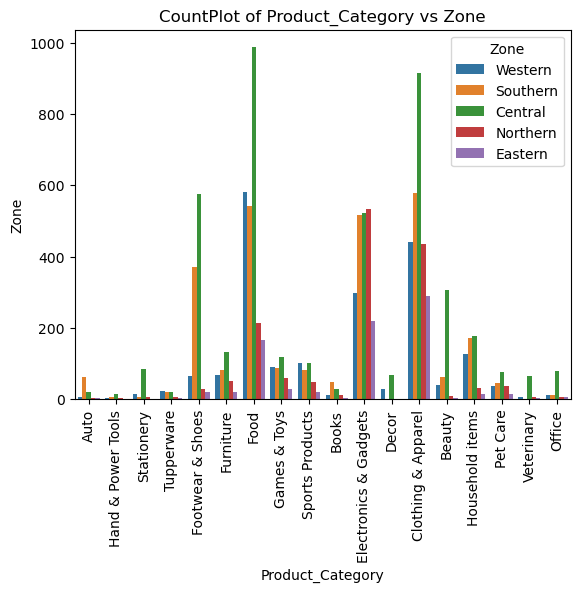

In [85]:
CategoricalVsCategorical(cleaned_data,"Product_Category","Zone")

# Multivariate Anlaysis

In [86]:
def multiVariateAnalysis(df,plot="heatmap"):
    if plot == "heatmap":
        sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
        plt.title("Correlation Heatmap")
        plt.show()
    elif plot == "pair":
        sns.pairplot(df)
        plt.suptitle("Pair plot of selected Features", y=1.02)
        plt.show()
    else:
        print("Invalid Plot")
        

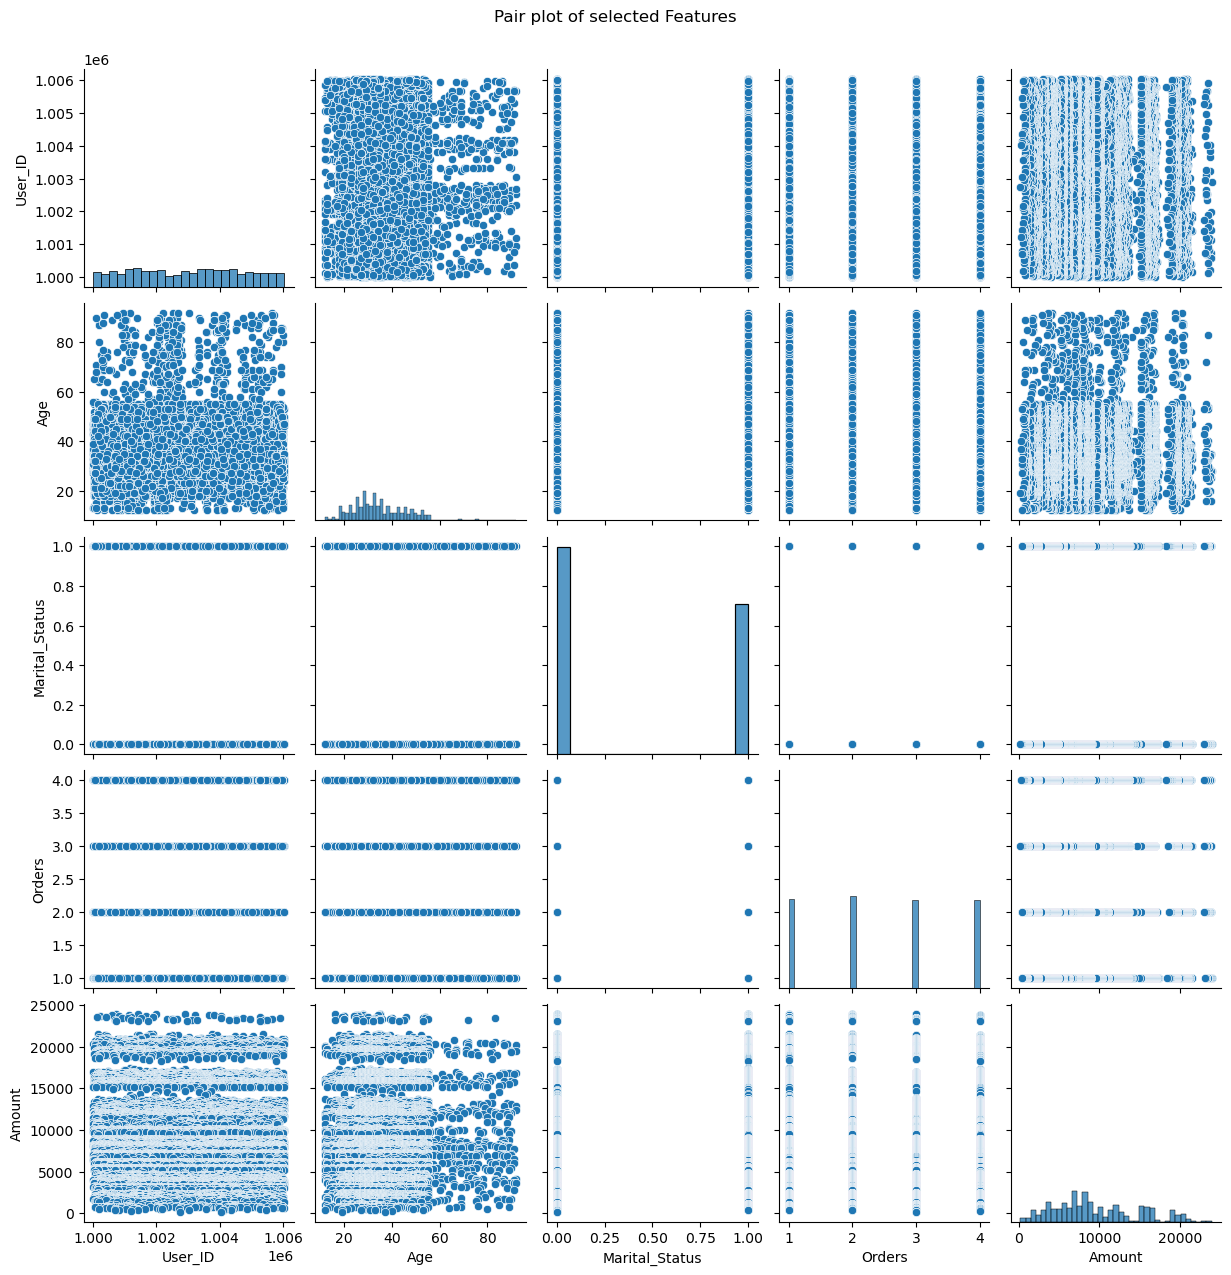

In [87]:
multiVariateAnalysis(cleaned_data,"pair")

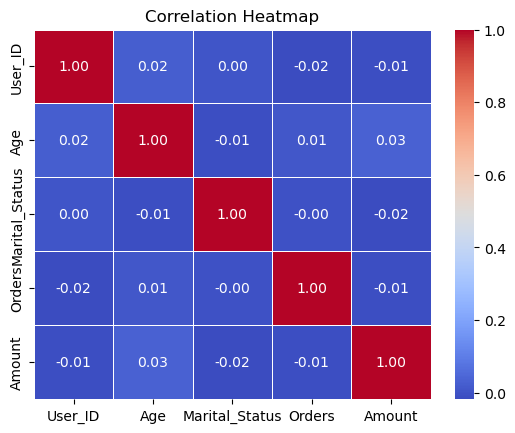

In [88]:
sns.heatmap(cleaned_data[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

# <h1 style = 'color:red;'>Final Analysis<h1/>